In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import os
os.chdir('/fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/')

In [2]:
from process_eval_results import load_all, filter_best_fit, plot_id_vs_ood, PROJECT_ROOT

# ── Config ──
k_plot = [1, 16, 32, 64, 128]

# preferred_size: use "400M" to pick only 400M (fallback to largest available).
# Set to None to pool all model sizes together onto one line per family.
preferred_size = None  # or "400M"

# OOD grouping: customise the op ranges for OOD subplots.
# Default: {"OOD-mid (op 11-14)": range(11,15), "OOD-hard (op 17-20)": range(17,21)}
# Alternative single-panel: {"OOD (op 11-20)": list(range(11, 21))}
# Alternative symmetric: {"OOD-mid (op 11-15)": list(range(11, 16)), "OOD-hard (op 16-20)": list(range(16, 21))}
ood_groups = None  # use default

# ── Load ──
df = load_all(
    max_ckpts=30,
    k_values=k_plot,
    preferred_size=preferred_size,
    ood_groups=ood_groups,
    to_percent=True,
    verbose=True,
)
print(f"\nLoaded {len(df)} rows")
print(df.groupby("family")["checkpoint"].nunique().to_string())
df.head()


[discover] transformer  pt_200M_ar_20260223_120306  size=200M
[discover] transformer  pt_400M_ar_20260223_160500  size=400M
[discover] transformer  pt_op2-10_10B_alltemps_20260213_233838  size=100M
[discover] bd3lm        a2d_bd3lm_100M_20260221_145059  size=100M  bs=32
[discover] bd3lm        a2d_bd3lm_200M_20260223_120716  size=200M  bs=32
[discover] bd3lm        a2d_bd3lm_200M_20260223_221022  size=200M  bs=128
[discover] bd3lm        a2d_bd3lm_400M_20260223_203350  size=400M  bs=32
[discover] bd3lm        a2d_bd3lm_400M_20260224_062453  size=400M  bs=128
[discover] mdlm         a2d_mdlm_100M_20260221_144133  size=100M

Loaded 1088 rows
family
BD3LM (bs=128)    19
BD3LM (bs=32)     21
MDLM               8
Transformer       10


,family,model_type,size,block_size,run_name,checkpoint,step,group,k,pass_at_k
0,BD3LM (bs=128),bd3lm,400M,128.0,a2d_bd3lm_400M_20260224_062453,checkpoint-500,500,ID,1,22.195747
1,BD3LM (bs=128),bd3lm,400M,128.0,a2d_bd3lm_400M_20260224_062453,checkpoint-500,500,OOD-hard (op=16-20),1,13.170312
2,BD3LM (bs=128),bd3lm,400M,128.0,a2d_bd3lm_400M_20260224_062453,checkpoint-500,500,ID,16,47.532342
3,BD3LM (bs=128),bd3lm,400M,128.0,a2d_bd3lm_400M_20260224_062453,checkpoint-500,500,OOD-hard (op=16-20),16,36.296412
4,BD3LM (bs=128),bd3lm,400M,128.0,a2d_bd3lm_400M_20260224_062453,checkpoint-500,500,ID,32,52.647662


[best_fit] BD3LM (bs=128): kept 15/34 checkpoints (avg residual range: 0.0005 – 0.0917)
[best_fit] BD3LM (bs=32): kept 15/40 checkpoints (avg residual range: 0.0008 – 0.3090)
[best_fit] MDLM: kept 8/8 checkpoints (avg residual range: 0.0047 – 0.0389)
[best_fit] Transformer: kept 15/30 checkpoints (avg residual range: 0.0017 – 0.0492)
After best-fit filter: {'BD3LM (bs=128)': 14, 'BD3LM (bs=32)': 13, 'MDLM': 8, 'Transformer': 10}


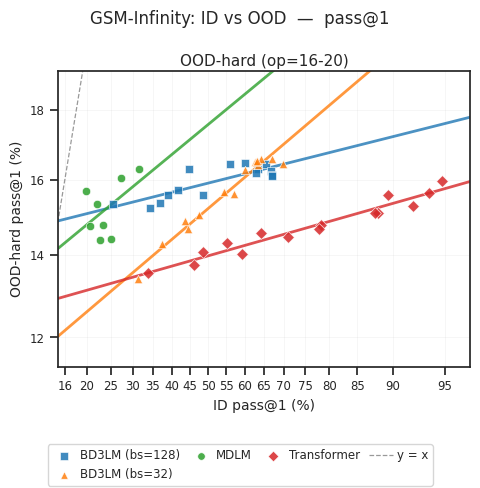

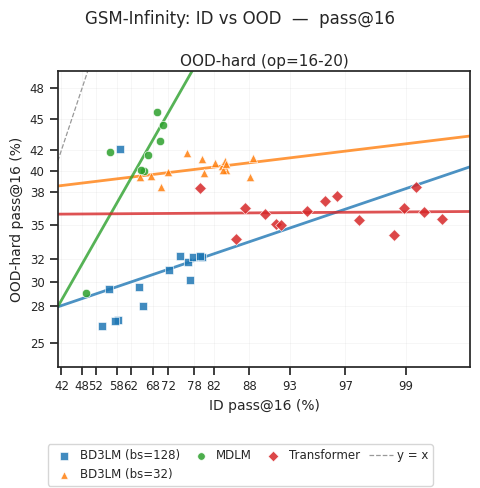

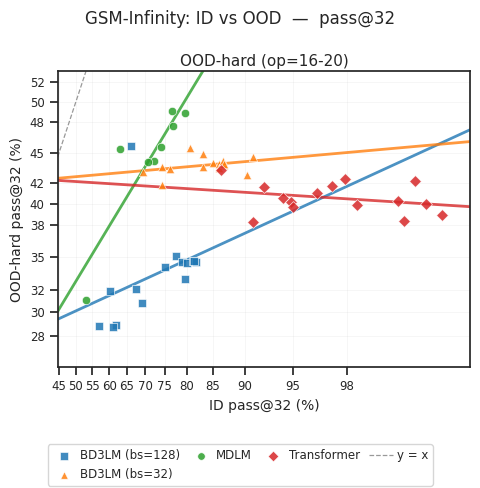

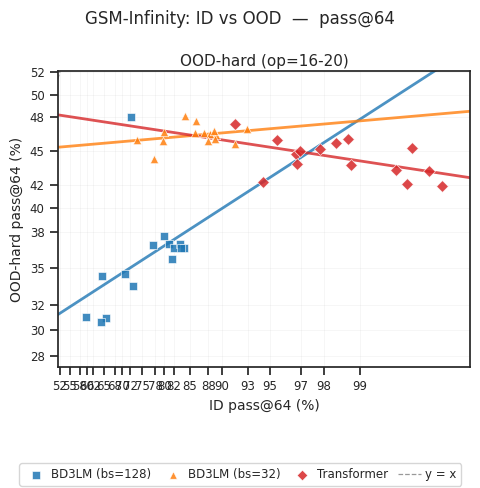

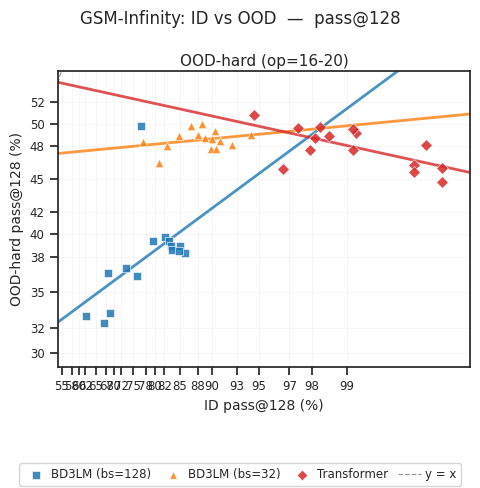

Saved to /lustre/fast/fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/figures/id_vs_ood


In [5]:
save_dir = PROJECT_ROOT / "analyze" / "figures" / "id_vs_ood"

# Families to exclude from plots (set to [] to include everything)
#exclude = ["BD3LM (bs=128)"]
exclude = []

# Best-fit filtering: keep only checkpoints that sit tightest on the probit line.
# Set best_fit_n = None to disable.  Residuals are computed using k_for_fit.
best_fit_n = 15 # e.g. 8 to keep 8 tightest per family, None to keep all
k_for_fit = 1

df_plot = df.copy()
if best_fit_n is not None:
    df_plot = filter_best_fit(df_plot, n=best_fit_n, k_for_fit=k_for_fit, verbose=True)
    print(f"After best-fit filter: {df_plot.groupby('family')['checkpoint'].nunique().to_dict()}")

plot_id_vs_ood(
    df_plot,
    k_values=k_plot,
    exclude_families=exclude,
    title="GSM-Infinity: ID vs OOD",
    save_dir=save_dir,
)
print(f"Saved to {save_dir}")